# Visualize chosem MEI order 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns
import pickle
import sys

repo_path = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/"
sys.path.append(repo_path)

import thesis.code.validate_online_meis.utils as ut

In [3]:
from thesis.code.plot import plot as plotter

plotter.set_default_params(kind='paper')

In [4]:
DATA_DIR = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/data/validate_online_meis"
FIG_DIR = "/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/thesis/figures/validate_online_meis"
os.makedirs(FIG_DIR, exist_ok=True)

In [7]:
# load data
ensemble_wrapper_save_dir = "GCL0_20251003_212914_refined_ensemble"
mei_data_container, neuron_data_dict, new_session_id, roi2readout_idx_wmeis = ut.load_wrapper_data_for_subset_selection(
    os.path.join(DATA_DIR, ensemble_wrapper_save_dir)
)

In [25]:
# compute mei order
from model_in_the_loop.utils.mei_subset_selection import select_subset_of_meis_for_each_roi
some_roi_ids = [61,39,46,26,40,71,25]
readout_idx_wmei2rois ={v: k for k, v in roi2readout_idx_wmeis.items()}

roi_id2mei_id,roi_id2info = select_subset_of_meis_for_each_roi(
    only_consider_these_rois =  some_roi_ids,
    mei_data_container=mei_data_container,
    neuron_data_dict=neuron_data_dict,
    new_session_id=new_session_id,
    readout_idx_wmei2rois=readout_idx_wmei2rois,
)

All responses [6.847821235656738, 8.795930862426758, 9.207071304321289, 8.94609546661377, 5.8082404136657715, 2.215487480163574]
all celltypes [11, 11, 1, 11, 32, 32]
all meis ['roi_61_seed_111', 'roi_71_seed_111', 'roi_26_seed_111', 'roi_46_seed_111', 'roi_39_seed_111', 'roi_25_seed_111']
All responses [5.44675350189209, 3.756974458694458, 6.685904026031494, 6.191373348236084, 3.658539295196533, 3.4185147285461426]
all celltypes [32, 32, 1, 11, 17, 11]
all meis ['roi_39_seed_111', 'roi_25_seed_111', 'roi_26_seed_111', 'roi_71_seed_111', 'roi_40_seed_111', 'roi_61_seed_111']
All responses [9.826196670532227, 9.735830307006836, 10.253873825073242, 6.590169429779053, 5.8500075340271, 2.153104066848755]
all celltypes [11, 11, 1, 11, 32, 32]
all meis ['roi_46_seed_111', 'roi_71_seed_111', 'roi_26_seed_111', 'roi_61_seed_111', 'roi_39_seed_111', 'roi_25_seed_111']
All responses [12.954455375671387, 12.262405395507812, 12.259336471557617, 7.580201148986816, 6.949462890625, 2.926143169403076]

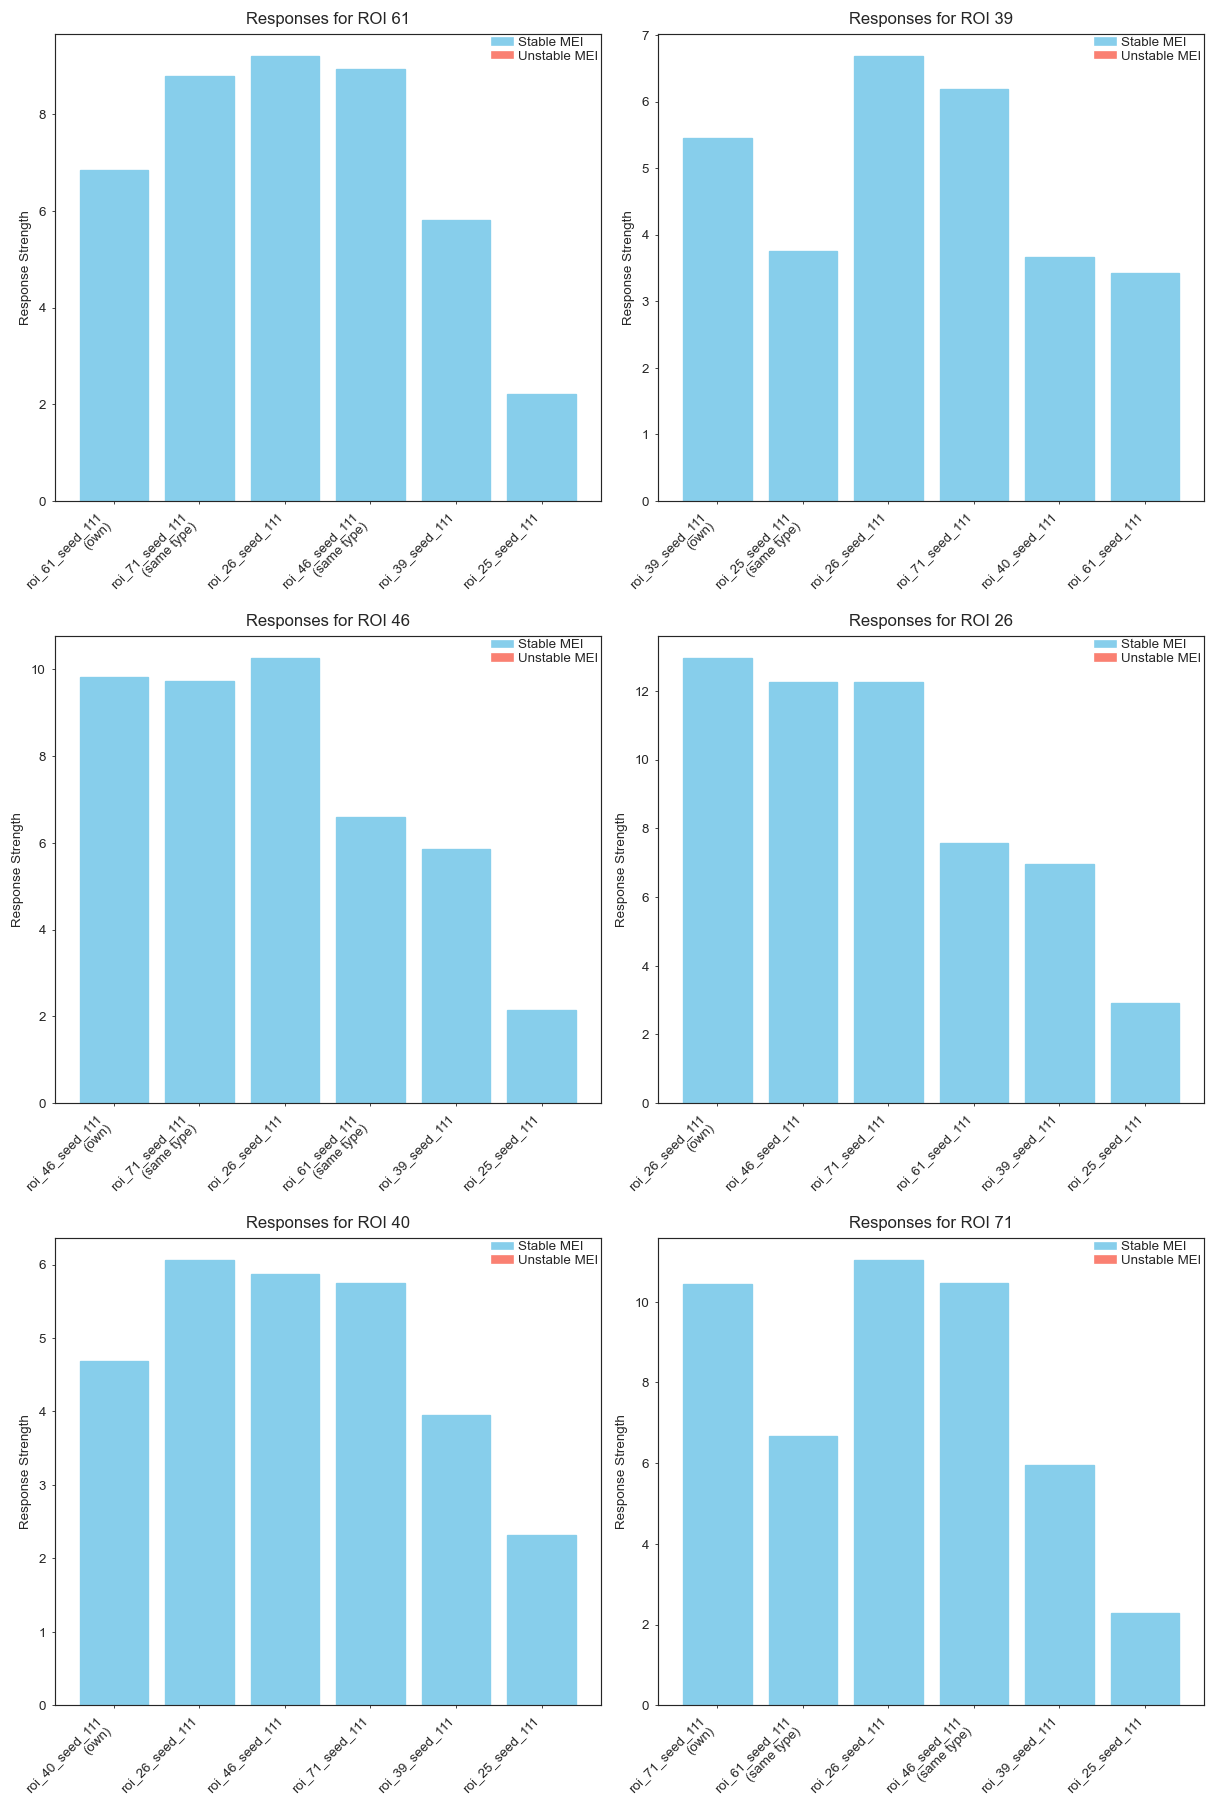

In [34]:
fig,axes = plt.subplots(3,2,figsize=(10,15))
axes = axes.flatten()
for i in range(len(some_roi_ids) - 1):
    fig,ax = ut.plot_responses_and_mei_info_one_roi(
        roi_id= some_roi_ids[i],
        roi_id2mei_ids = roi_id2mei_id,
        roi_id2info = roi_id2info,
        ax = axes[i],
    )

plotter.tight_layout()


In [39]:
roi2readout_idx_wmeis

{5: 0,
 7: 1,
 8: 2,
 14: 3,
 15: 4,
 21: 5,
 22: 6,
 24: 7,
 25: 8,
 26: 9,
 27: 10,
 28: 11,
 29: 12,
 34: 13,
 36: 15,
 38: 16,
 39: 17,
 40: 18,
 41: 19,
 42: 20,
 44: 21,
 45: 22,
 46: 23,
 47: 24,
 48: 25,
 49: 26,
 51: 27,
 56: 29,
 59: 30,
 60: 31,
 61: 32,
 62: 33,
 63: 34,
 67: 35,
 68: 36,
 71: 37,
 73: 38,
 74: 39,
 78: 40,
 81: 41,
 84: 42,
 86: 43,
 89: 44,
 91: 45,
 93: 47,
 94: 48,
 102: 49,
 103: 50}

In [ ]:
list(readout_idx_wmei2rois.keys())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 47,
 48,
 49,
 50]

All responses [9.891495704650879, 9.335443496704102, 10.057106971740723, 9.940530776977539, 1.3716551065444946, 1.3700239658355713]
all celltypes [1, 1, 9, 12, 27, 27]
all meis ['roi_5_seed_111', 'roi_94_seed_111', 'roi_68_seed_111', 'roi_44_seed_111', 'roi_51_seed_222', 'roi_51_seed_111']
All responses [11.5828275680542, 8.811214447021484, 11.540480613708496, 11.483777046203613, 0.7460081577301025, 0.7121112942695618]
all celltypes [17, 17, 13, 17, 4, 7]
all meis ['roi_7_seed_111', 'roi_22_seed_111', 'roi_62_seed_111', 'roi_24_seed_111', 'roi_42_seed_111', 'roi_15_seed_111']
All responses [4.421619415283203, 4.751136779785156, 7.42092752456665, 7.34664249420166, 0.5787695646286011, 0.5750154852867126]
all celltypes [31, 31, 9, 8, 4, 12]
all meis ['roi_8_seed_111', 'roi_81_seed_111', 'roi_68_seed_111', 'roi_45_seed_111', 'roi_42_seed_111', 'roi_84_seed_111']
All responses [5.446211814880371, 3.9921295642852783, 5.709826946258545, 5.616510391235352, 0.8111279606819153, 0.692785143852233

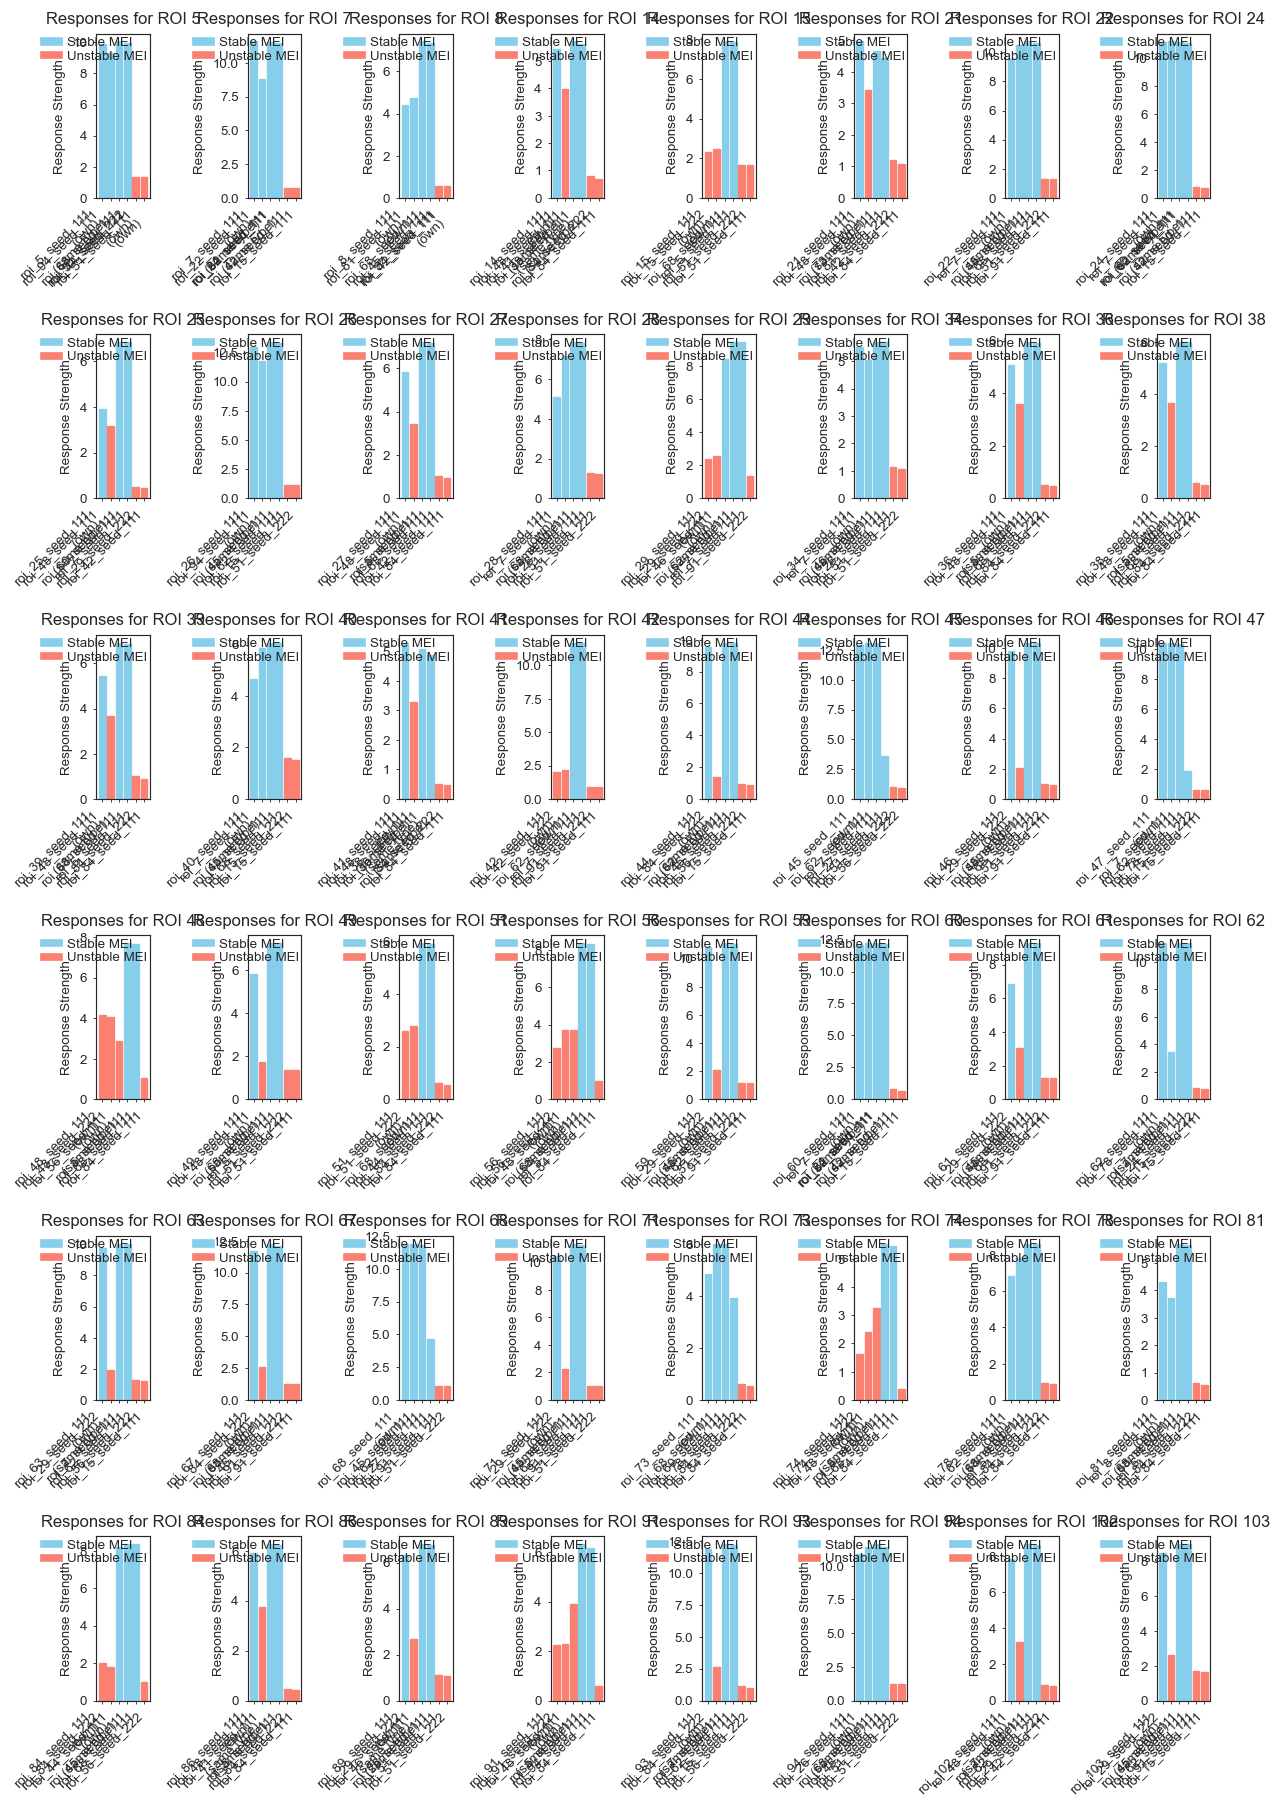

In [40]:
# lets look at all 
def plot_all_rois(readout_idx_wmei2rois,
                  ):
    all_roi_ids = list(readout_idx_wmei2rois.values())


    roi_id2mei_id,roi_id2info = select_subset_of_meis_for_each_roi(
        only_consider_these_rois =  all_roi_ids,
        mei_data_container=mei_data_container,
        neuron_data_dict=neuron_data_dict,
        new_session_id=new_session_id,
        readout_idx_wmei2rois=readout_idx_wmei2rois,
    )
    n_rows = np.sqrt(len(all_roi_ids)).astype(int)
    n_cols = int(np.ceil(len(all_roi_ids)/n_rows))
    fig,axes = plt.subplots(n_rows,n_cols,figsize=(10,15))
    axes = axes.flatten()
    for ax,roi in zip(axes, all_roi_ids):
        fig,ax = ut.plot_responses_and_mei_info_one_roi(
            roi_id= roi,
            roi_id2mei_ids = roi_id2mei_id,
            roi_id2info = roi_id2info,
            ax = ax,
        )


    plotter.tight_layout()

plot_all_rois(readout_idx_wmei2rois)